In [1]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
import tensorflow as tf
import keras

train_ds = keras.utils.image_dataset_from_directory(
    path+"/Training",
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    color_mode="grayscale"
) 

test_ds = keras.utils.image_dataset_from_directory(
    path+"/Testing",
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    color_mode="grayscale")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [23]:
X_train, y_train, X_test, y_test = [], [], [], []

for image, label in train_ds:
	X_train.append(image)
	y_train.append(label)

for image, label in test_ds:
	X_test.append(image)
	y_test.append(label)

X_train = tf.concat(X_train,axis=0) / 255.0
y_train = tf.concat(y_train,axis=0) 
X_test = tf.concat(X_test,axis=0) / 255.0 
y_test = tf.concat(y_test,axis=0)

In [24]:
len(X_train), len(y_train), len(X_test), len(y_test)

(5600, 5600, 1600, 1600)

(<matplotlib.image.AxesImage at 0x2bb553dafd0>,
 <tf.Tensor: shape=(), dtype=int32, numpy=1>)

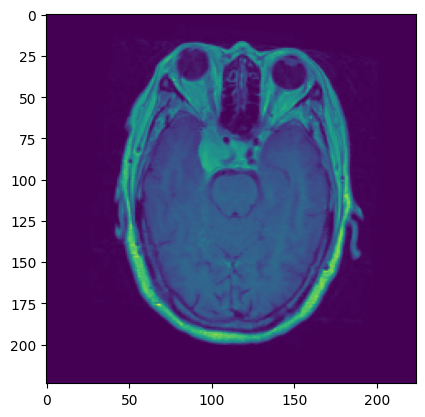

In [25]:
import matplotlib.pyplot as mtp

mtp.imshow(X_train[0]), y_train[0]

In [6]:
from keras.callbacks import EarlyStopping 
from keras import Sequential, Input, regularizers
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,RandomFlip,RandomRotation

In [9]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3), padding="same"),
	MaxPooling2D((2,2)),

	Conv2D(64,(3,3),activation="relu"),
	MaxPooling2D((2,2)),

	Flatten(),

	Dense(64,activation="relu"),
	Dropout(0.5),
	Dense(32,activation="relu"),
	Dropout(0.5),
	Dense(4,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 110, 110, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 193600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │    12,390,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,412,068 (47.35 MB)

 Trainable params: 12,412,068 (47.35 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.fit(X_train,y_train,batch_size=32,epochs=50,callbacks=[early_stopping],validation_split=0.2,shuffle=False)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.3714 - loss: 1.3601 - val_accuracy: 0.6687 - val_loss: 0.8799
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.5629 - loss: 0.9582 - val_accuracy: 0.7455 - val_loss: 0.7167
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.6036 - loss: 0.8500 - val_accuracy: 0.7509 - val_loss: 0.5909
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.6551 - loss: 0.7383 - val_accuracy: 0.8018 - val_loss: 0.5942
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.6853 - loss: 0.6766 - val_accuracy: 0.8339 - val_loss: 0.6012
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 927s 7s/step - accuracy: 0.7395 - loss: 0.6120 - val_accuracy: 0.8598 - val_loss: 0.5322
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 968s 7s/step - accuracy: 0.7618 - loss: 0.5621 - val_accuracy: 0.8670 - val_loss: 0.4619
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7824 - loss: 0.5149 - val_accu

In [9]:
model.evaluate(X_test,y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 606ms/step - accuracy: 0.8313 - loss: 0.8782


[0.8782079219818115, 0.831250011920929]

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

data_augmentation = Sequential([
	RandomFlip("horizontal_and_vertical"),
	RandomRotation(0.2),
])

model2 = Sequential([
    Input(shape=(224,224,3)),
	data_augmentation,

	Conv2D(32,(3,3),activation="relu"),
	MaxPooling2D((2,2)),

	Conv2D(64,(3,3),activation="relu"),
	MaxPooling2D((2,2)),

	Flatten(),

	Dense(64,activation="relu",kernel_regularizer=regularizers.l2(0.01)),
	Dropout(0.3),
	Dense(32,activation="relu",kernel_regularizer=regularizers.l2(0.01)),	
	Dropout(0.3),
	Dense(4,activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,965,604 (45.65 MB)

 Trainable params: 11,965,604 (45.65 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model2.fit(X_train,y_train,batch_size=32,epochs=50,callbacks=[early_stopping],validation_split=0.2,shuffle=False)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.4502 - loss: 1.7621 - val_accuracy: 0.6313 - val_loss: 1.2393
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.5830 - loss: 1.2715 - val_accuracy: 0.7071 - val_loss: 1.0704
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.6163 - loss: 1.1639 - val_accuracy: 0.6277 - val_loss: 1.0626
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.6379 - loss: 1.0897 - val_accuracy: 0.7250 - val_loss: 0.9642
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.6685 - loss: 1.0394 - val_accuracy: 0.7223 - val_loss: 0.9332
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 1212s 9s/step - accuracy: 0.6819 - loss: 1.0172 - val_accuracy: 0.7491 - val_loss: 0.8772
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.6857 - loss: 1.0105 - val_accuracy: 0.7080 - val_loss: 0.9200
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.6935 - loss: 0.9781 - val_acc

In [21]:
model2.evaluate(X_test,y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 413ms/step - accuracy: 0.7100 - loss: 1.1348


[1.1348025798797607, 0.7099999785423279]